# Import libraries

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load Ground Truth

In [2]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

### Load full ground truth

In [3]:
gt_df = load_gt("../data/charades/annotations/charades.json")

# Load ground truth function

### Load sample ground truth (10 least frequent classes)

In [4]:
least_sample_gt_df = load_gt("../data/charades/annotations/least_sample_charades.json")
print(least_sample_gt_df.shape)
least_sample_gt_df.head()

(449, 6)


,video_id,duration,subset,start,end,label
0,028CE,20.00,training,2.0,11.0,Fixing a vacuum
1,03EW0,31.12,training,0.0,2.6,Throwing a box somewhere
2,06EDS,35.46,training,23.6,36.0,Making a sandwich
3,08AQS,32.33,training,29.1,33.0,Throwing a box somewhere
4,08LOY,28.04,testing,5.7,21.9,Fixing a light


### Load sample ground truth (10 most frequent classes)

In [5]:
most_sample_gt_df = load_gt("../data/charades/annotations/most_sample_charades.json")
print(most_sample_gt_df.shape)
most_sample_gt_df.head()

(4613, 6)


,video_id,duration,subset,start,end,label
0,004QE,30.58,training,14.2,22.5,Drinking from a cup/glass/bottle
1,004QE,30.58,training,0.0,32.0,Holding a cup/glass/bottle of something
2,004QE,30.58,training,9.9,21.3,Someone is standing up from somewhere
3,004QE,30.58,training,3.2,11.2,Someone is going from standing to sitting
4,004QE,30.58,training,1.1,7.1,Walking through a doorway


### Load predictions

In [6]:
with open("../exps/charades/actionformer_i3d_rgb/result_detection.json", "r") as f:
  predictions = json.load(f)

rows_predictions = []
for video_id, segments in predictions['results'].items():
  for s in segments:
    rows_predictions.append({
      'video_id': video_id,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label'],
      'score': s['score']
    })
  
predictions_df = pd.DataFrame(rows_predictions)
predictions_df.sample(50)

,video_id,start,end,label,score
56735,OB9D0,14.45,16.26,Drinking from a cup/glass/bottle,0.0035
24505,AWN1C,-0.00,36.08,Walking through a doorway,0.0093
3816,1HYO4,13.62,15.70,Drinking from a cup/glass/bottle,0.0174
90378,ZXHCH,12.72,14.56,Walking through a doorway,0.0052
73438,U588C,1.24,3.28,Holding some food,0.0077
28372,BW2OT,6.29,8.32,Drinking from a cup/glass/bottle,0.0017
21833,AAQHJ,-0.00,11.85,Holding some food,0.0020
81821,WLV4Q,22.15,23.97,Holding a cup/glass/bottle of something,0.0079
90578,ZXHCH,11.00,12.88,Walking through a doorway,0.0010
39554,HB02D,0.28,6.94,Holding a phone/camera,0.0703


In [7]:
predictions_df.shape

(90584, 5)

# Plot Predictions against Ground Truth

In [8]:
def plot_predictions_vs_gt(predictions_df, gt_df, video_id, confidence_threshold=0.04):
    # predictions for the video
    predicted_video = predictions_df[
        (predictions_df["video_id"] == video_id)
        & (predictions_df["score"] > confidence_threshold)
    ]
    # ground truth for the video
    video = gt_df[gt_df["video_id"] == video_id]

    # Plot predictions against ground truth
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for _, row in predicted_video.iterrows():
        ax[0].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[0].set_title("Prediction")

    for _, row in video.iterrows():
        ax[1].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[1].set_title("Ground Truth")

    plt.xlabel("Second")
    plt.tight_layout()
    plt.show()

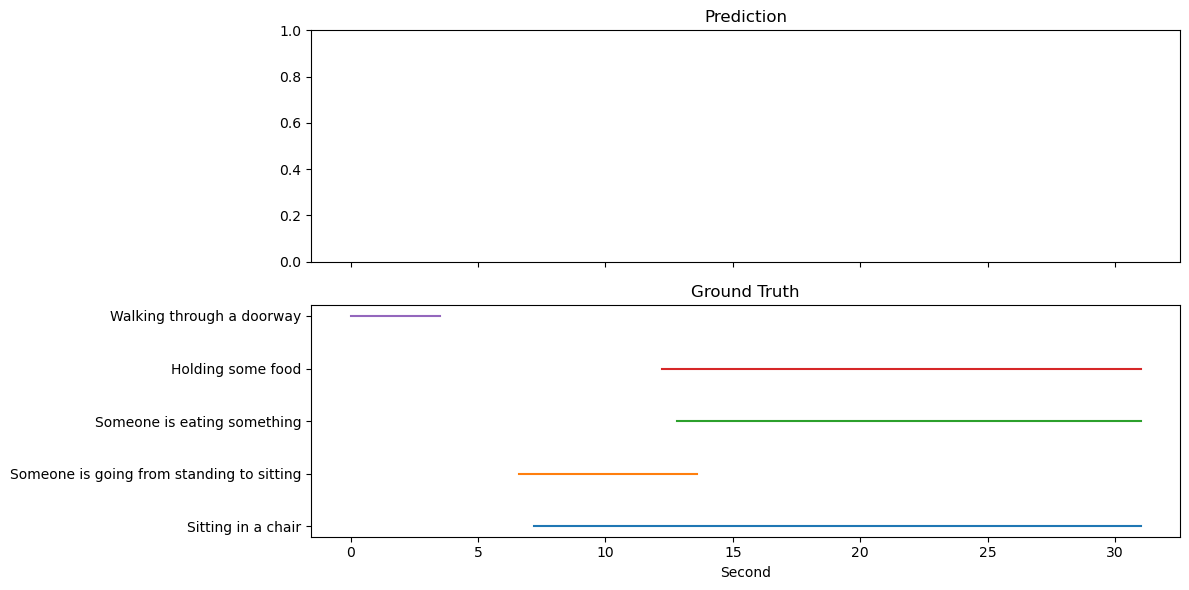

In [9]:
plot_predictions_vs_gt(predictions_df, most_sample_gt_df, "0TDOP", confidence_threshold=0.3)

# Overlapping Analysis

In [10]:
def calculate_overlap_density(df, video_id):
    # Filter rows for the given video
    video_df = df[df["video_id"] == video_id].copy()

    if len(video_df) < 2:
        return 0.0  # No overlap possible with fewer than 2 segments

    # Get total video duration (assume all rows have the same duration)
    total_duration = video_df["duration"].iloc[0]

    # Build a list of (start, end) tuples
    intervals = list(zip(video_df["start"], video_df["end"]))

    # Create a timeline of second-level granularity
    timeline = [0.0] * int(total_duration * 10)  # use deci-seconds for precision

    # Mark timeline per action
    for start, end in intervals:
        for t in range(int(start * 10), int(end * 10)):
            if 0 <= t < len(timeline):
                timeline[t] += 1

    # Count overlapping time points (where >1 action occurs)
    overlap_count = sum(1 for t in timeline if t > 1)

    # Convert back to seconds
    overlap_duration = overlap_count / 10.0

    # Compute and return overlap density
    return overlap_duration / total_duration

In [11]:
gt_df['overlap_density'] = gt_df['video_id'].apply(lambda x: calculate_overlap_density(gt_df, x))
gt_df['overlap_density'].describe()

count    66500.000000
mean         0.808586
std          0.230699
min          0.000000
25%          0.680897
50%          0.904402
75%          0.997545
max          1.000000
Name: overlap_density, dtype: float64

# Check the number of frames

In [14]:
ego_df = pd.read_csv("../data/charades/annotations/CharadesEgo_v1_train_only1st.csv")
ego_df.head()

,id,subject,scene,quality,relevance,verified,script,objects,descriptions,actions,length,egocentric,charades_video
0,D3TR8EGO,2Q9D,Closet / Walk-in closet / Spear closet,7.0,7.0,Yes,A person walks into the closet and turns on th...,cup/glass/bottle;door;food;glass of water;ligh...,The person in the video walks into a room and ...,c156 3.90 12.00;c061 8.20 12.50;c106 9.90 18.4...,31.79,Yes,1K0SU
1,65JW9EGO,ZG1V,Living room,3.0,7.0,Yes,"A person was walking towards the sofa, and tak...",couch;floor;food;glass;pillow;table;window,A person walks into a room and grabs a pillow ...,c109 19.90 24.29;c107 16.80 23.80;c106 10.10 2...,27.38,Yes,NaN
2,3UML4EGO,0AC0,Home Office / Study (A room in a house used fo...,7.0,7.0,Yes,A person is sitting in a chair in their home o...,chair;coffee;cup;desk;phone;table,person is sitting on a chair playing on the ph...,c107 16.50 22.04;c110 15.30 21.00;c109 23.10 2...,26.75,Yes,NaN
3,6U5TEEGO,5LWB,Bathroom,6.0,6.0,Yes,One person washes a mirror and tidies up while...,blanket;cloth;mirror;sofa/couch;towel,A person cleans mirror and another person take...,c073 14.90 20.00;c095 0.00 15.90;c070 10.20 20...,21.75,Yes,YFZRG
4,KCSBQEGO,UN1T,Living room,6.0,5.0,Yes,A smiling person is fixing a window in their l...,tool;towel;window,The person appears to be fixing a window in th...,NaN,35.67,Yes,SKUOZ


In [ ]:
import os

def is_same_noframes(exo_id, ego_id):
    rgb_path = f"../data/charades/CharadesEgo_v1_rgb"
    exo_rgb_dir = rgb_path + f"/{exo_id}"
    ego_rgb_dir = rgb_path + f"/{ego_id}"

    # Make sure both directories exist
    if not os.path.isdir(exo_rgb_dir) or not os.path.isdir(ego_rgb_dir):
        return False

    exo_frames = os.listdir(exo_rgb_dir)
    ego_frames = os.listdir(ego_rgb_dir)
    
    noframes_diff = len(exo_frames) - len(ego_frames)
    
    # Check if the number of frames in both directories are similar
    return abs(noframes_diff) < 5 # consider to change this
  
def get_ego_id_from_charades_video_id(df, video_id):
    ego_id = df[df['charades_video'] == video_id]['id']
    if len(ego_id) == 0:
      return None
    return ego_id.iloc[0] if isinstance(ego_id, pd.Series) else ego_id

In [76]:
get_ego_id_from_charades_video_id(ego_df, "ZSHV8")

'0Q8QTEGO'

In [50]:
ego_df['is_same_noframes'] = ego_df.apply(lambda row: is_same_noframes(row['id'][:-3], row['id']), axis=1)

In [51]:
ego_df[ego_df['is_same_noframes'] == True]['id'].nunique()

260

In [52]:
ego_df[ego_df['is_same_noframes'] == True].head()

,id,subject,scene,quality,relevance,verified,script,objects,descriptions,actions,length,egocentric,charades_video,is_same_noframe,is_same_noframes
25,44BSTEGO,X5EU,Bathroom,6.0,6.0,Yes,The person starts laughing while she's washing...,bathtub;clothes;doorway;medicine;mirror;paper/...,"A person walks into a bathroom, throws shoes i...",c129 8.10 12.90;c015 0.00 13.21;c096 6.40 11.1...,13.21,Yes,NaN,False,True
26,0K09ZEGO,ROBJ,Living room,4.0,3.0,Yes,"One person grasps a book from a cabinet, then ...",book;chair;closet/cabinet;cup/glass/bottle;doo...,The person get a book in the drawer and sat in...,c097 3.00 32.96;c106 8.20 32.96;c059 15.00 32....,32.96,Yes,F207R,False,True
44,GCQDHEGO,XH2Y,Bedroom,7.0,7.0,Yes,A laptop sits on the cabinet a person is walki...,bed;cabinet;laptop;sofa/couch,A person is standing near the cabinet and snee...,c151 6.40 14.70;c050 4.60 20.00;c047 7.20 20.0...,19.96,Yes,UYJVE,False,True
47,HLI6XEGO,U259,Bedroom,5.0,5.0,Yes,One person is sitting on a pillow drinking whe...,bag;bed;doorway;glass;medicine,person is sitting in bed drinking from a glass...,c128 3.00 7.29;c129 1.30 7.29;c106 0.00 7.29;c...,7.38,Yes,7KAVM,False,True
48,GTWBTEGO,X5EU,Kitchen,7.0,7.0,Yes,one person in the kitching snuggling with a pi...,clothes;door;floor;medicine;mirror;shoe,nothing,c054 4.60 9.90;c128 7.90 13.21;c126 4.40 9.30;...,13.21,Yes,NaN,False,True
